In [1]:
import os
import pandas as pd
from PIL import Image
import numpy as np
from collections import Counter
from tqdm import tqdm


In [2]:
DATA_ROOT = "/mnt/c/Development/ai-gen-detection/shard_0/shard_0"
IMAGE_DIR = f"{DATA_ROOT}/images"
LABEL_CSV = f"{DATA_ROOT}/labels.csv"


In [3]:
df = pd.read_csv(LABEL_CSV)
print(df.head())
print(df.columns)



   Unnamed: 0                image_name  label
0           0  ed97447bcc3cea21bfa2.jpg      0
1           1  8252d6ad09a67674576a.jpg      0
2           2  01a84d7398e97a047b7c.jpg      1
3           3  0c6a4e6cca4e9e582cf9.jpg      1
4           4  99aec474f7ef493820c9.jpg      1
Index(['Unnamed: 0', 'image_name', 'label'], dtype='object')


In [4]:
print(df)

       Unnamed: 0                image_name  label
0               0  ed97447bcc3cea21bfa2.jpg      0
1               1  8252d6ad09a67674576a.jpg      0
2               2  01a84d7398e97a047b7c.jpg      1
3               3  0c6a4e6cca4e9e582cf9.jpg      1
4               4  99aec474f7ef493820c9.jpg      1
...           ...                       ...    ...
49995       49995  e57829db65c2c043a653.jpg      0
49996       49996  fc7d12e61c9e407d2727.jpg      0
49997       49997  035d9c181765c89235c1.jpg      1
49998       49998  009e3e1df8af2b1f8976.jpg      1
49999       49999  3d594f3eaf6330c23e9f.jpg      1

[50000 rows x 3 columns]


In [5]:
# FNAME_COL = "image_name"   # change if needed
# LABEL_COL = "label"      # change if needed

# samples = []
# i = 0
# for _, row in df.iterrows():
#     img_path = os.path.join(IMAGE_DIR, row[FNAME_COL])
#     if i % 1000 == 0:
#         print(i, ":", img_path)

#     if os.path.exists(img_path):
#         samples.append({
#             "path": img_path,
#             "label": int(row[LABEL_COL])
#         })
#     else:
#         print(f"Missing image: {row[FNAME_COL]}")
#     i = i + 1

# print(f"Total valid samples: {len(samples)}")


In [6]:
import os

FNAME_COL = "image_name"
LABEL_COL = "label"

# 1️⃣ Get all existing image filenames once
existing_files = set(os.listdir(IMAGE_DIR))

# 2️⃣ Filter dataframe in vectorized way
df_valid = df[df[FNAME_COL].isin(existing_files)]

# 3️⃣ Build samples list (fast)
samples = [
    {
        "path": os.path.join(IMAGE_DIR, fname),
        "label": int(label)
    }
    for fname, label in zip(df_valid[FNAME_COL], df_valid[LABEL_COL])
]

print(f"Total valid samples: {len(samples)}")


Total valid samples: 50000


In [7]:
# =============================
# CELL — Resolution Statistics with JSON Caching
# =============================

import os
import cv2
import numpy as np
import json
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

OUTPUT_JSON = "resolution_stats.json"

# -------------------------------------------------
# If JSON already exists → Load and display
# -------------------------------------------------
if os.path.exists(OUTPUT_JSON):
    print(f"📂 Found existing {OUTPUT_JSON}. Loading cached results...\n")
    
    with open(OUTPUT_JSON, "r") as f:
        stats = json.load(f)
    
    print(json.dumps(stats, indent=4))
    
else:
    print(f"🚀 Processing {len(samples)} images using {cpu_count()} CPU cores...\n")

    def get_size(sample):
        path = sample["path"]
        img = cv2.imread(path)
        if img is None:
            return None
        h, w = img.shape[:2]
        return (w, h)

    with Pool(cpu_count()) as pool:
        sizes = list(tqdm(pool.imap(get_size, samples), total=len(samples)))

    # Remove failed reads
    sizes = [s for s in sizes if s is not None]

    widths, heights = zip(*sizes)
    widths = np.array(widths)
    heights = np.array(heights)

    stats = {
        "description": {
            "min_width": "Smallest image width in pixels.",
            "max_width": "Largest image width in pixels.",
            "mean_width": "Average image width.",
            "median_width": "Median image width.",
            "min_height": "Smallest image height in pixels.",
            "max_height": "Largest image height in pixels.",
            "mean_height": "Average image height.",
            "median_height": "Median image height.",
            "total_images_processed": "Number of successfully read images.",
            "aspect_ratio_mean": "Average width/height ratio.",
            "aspect_ratio_std": "Standard deviation of width/height ratio (variation in shape)."
        },
        "stats": {
            "min_width": int(widths.min()),
            "max_width": int(widths.max()),
            "mean_width": float(widths.mean()),
            "median_width": float(np.median(widths)),
            "min_height": int(heights.min()),
            "max_height": int(heights.max()),
            "mean_height": float(heights.mean()),
            "median_height": float(np.median(heights)),
            "total_images_processed": len(widths),
            "aspect_ratio_mean": float(np.mean(widths / heights)),
            "aspect_ratio_std": float(np.std(widths / heights))
        }
    }

    with open(OUTPUT_JSON, "w") as f:
        json.dump(stats, f, indent=4)

    print("\n✅ Resolution analysis complete.")
    print(f"Results saved to: {OUTPUT_JSON}")


📂 Found existing resolution_stats.json. Loading cached results...

{
    "description": {
        "min_width": "Smallest image width in pixels.",
        "max_width": "Largest image width in pixels.",
        "mean_width": "Average image width.",
        "median_width": "Median image width.",
        "min_height": "Smallest image height in pixels.",
        "max_height": "Largest image height in pixels.",
        "mean_height": "Average image height.",
        "median_height": "Median image height.",
        "total_images_processed": "Number of successfully read images.",
        "aspect_ratio_mean": "Average width/height ratio.",
        "aspect_ratio_std": "Standard deviation of width/height ratio (variation in shape)."
    },
    "stats": {
        "min_width": 256,
        "max_width": 4096,
        "mean_width": 1137.6048,
        "median_width": 1024.0,
        "min_height": 256,
        "max_height": 4096,
        "mean_height": 1110.23616,
        "median_height": 992.0,
      

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(widths, bins=30)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")
plt.show()


NameError: name 'widths' is not defined

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure()
plt.hist(heights, bins=30)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")
plt.show()


NameError: name 'heights' is not defined

<Figure size 640x480 with 0 Axes>

In [10]:
plt.figure(figsize=(15, 15))
plt.scatter(widths, heights)
plt.title("Width vs Height")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")
plt.show()


NameError: name 'widths' is not defined

<Figure size 1500x1500 with 0 Axes>

In [11]:
from collections import Counter

total = len(samples)
labels = []

print(f"Processing {total} labels...\n")

for i, sample in enumerate(samples):
    labels.append(sample["label"])
    
    if (i + 1) % max(1, total // 100) == 0 or i == total - 1:
        percent = ((i + 1) / total) * 100
        print(f"Progress: {percent:.2f}%")

label_counts = Counter(labels)

print("\n---- Class Distribution ----")
for label, count in label_counts.items():
    print(f"Class {label}: {count} samples ({100 * count / total:.2f}%)")


Processing 50000 labels...

Progress: 1.00%
Progress: 2.00%
Progress: 3.00%
Progress: 4.00%
Progress: 5.00%
Progress: 6.00%
Progress: 7.00%
Progress: 8.00%
Progress: 9.00%
Progress: 10.00%
Progress: 11.00%
Progress: 12.00%
Progress: 13.00%
Progress: 14.00%
Progress: 15.00%
Progress: 16.00%
Progress: 17.00%
Progress: 18.00%
Progress: 19.00%
Progress: 20.00%
Progress: 21.00%
Progress: 22.00%
Progress: 23.00%
Progress: 24.00%
Progress: 25.00%
Progress: 26.00%
Progress: 27.00%
Progress: 28.00%
Progress: 29.00%
Progress: 30.00%
Progress: 31.00%
Progress: 32.00%
Progress: 33.00%
Progress: 34.00%
Progress: 35.00%
Progress: 36.00%
Progress: 37.00%
Progress: 38.00%
Progress: 39.00%
Progress: 40.00%
Progress: 41.00%
Progress: 42.00%
Progress: 43.00%
Progress: 44.00%
Progress: 45.00%
Progress: 46.00%
Progress: 47.00%
Progress: 48.00%
Progress: 49.00%
Progress: 50.00%
Progress: 51.00%
Progress: 52.00%
Progress: 53.00%
Progress: 54.00%
Progress: 55.00%
Progress: 56.00%
Progress: 57.00%
Progress: 58

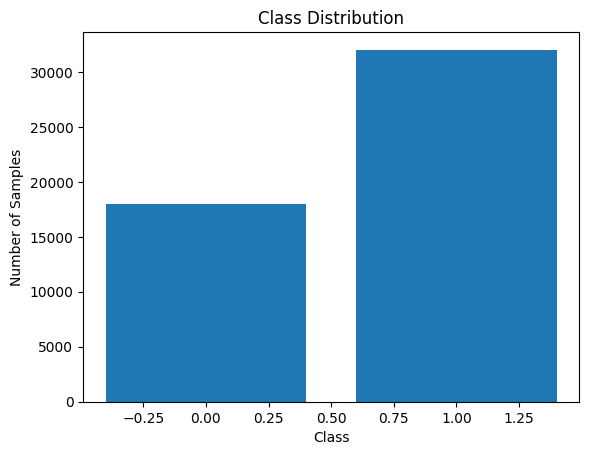

In [12]:
plt.figure()
plt.bar(label_counts.keys(), label_counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()


In [13]:
# =============================
# CELL — File Size Statistics (Multiprocessing + JSON Caching)
# =============================

import os
import numpy as np
import json
from multiprocessing import Pool, cpu_count
from tqdm import tqdm

OUTPUT_JSON = "file_size_stats.json"

# -------------------------------------------------
# If JSON already exists → Load and display
# -------------------------------------------------
if os.path.exists(OUTPUT_JSON):
    print(f"📂 Found existing {OUTPUT_JSON}. Loading cached results...\n")
    
    with open(OUTPUT_JSON, "r") as f:
        stats = json.load(f)
    
    print(json.dumps(stats, indent=4))

else:
    print(f"🚀 Processing {len(samples)} images using {cpu_count()} CPU cores...\n")

    def get_file_size(sample):
        try:
            size_kb = os.path.getsize(sample["path"]) / 1024
            return (size_kb, sample["label"])
        except:
            return None

    with Pool(cpu_count()) as pool:
        results = list(tqdm(pool.imap(get_file_size, samples), total=len(samples)))

    results = [r for r in results if r is not None]

    file_sizes_kb, labels_fs = zip(*results)
    file_sizes_kb = np.array(file_sizes_kb)
    labels_fs = np.array(labels_fs)

    # Overall stats
    overall_stats = {
        "min_kb": float(file_sizes_kb.min()),
        "max_kb": float(file_sizes_kb.max()),
        "mean_kb": float(file_sizes_kb.mean()),
        "median_kb": float(np.median(file_sizes_kb)),
        "std_kb": float(file_sizes_kb.std()),
        "total_images_processed": len(file_sizes_kb)
    }

    # Per-class stats (VERY useful for AI detection)
    class_stats = {}
    for cls in np.unique(labels_fs):
        cls_sizes = file_sizes_kb[labels_fs == cls]
        class_stats[int(cls)] = {
            "min_kb": float(cls_sizes.min()),
            "max_kb": float(cls_sizes.max()),
            "mean_kb": float(cls_sizes.mean()),
            "median_kb": float(np.median(cls_sizes)),
            "std_kb": float(cls_sizes.std()),
            "count": int(len(cls_sizes))
        }

    stats = {
        "description": {
            "min_kb": "Smallest file size in kilobytes.",
            "max_kb": "Largest file size in kilobytes.",
            "mean_kb": "Average file size.",
            "median_kb": "Median file size.",
            "std_kb": "Standard deviation of file sizes (spread).",
            "class_stats": "Statistics separated by class label (e.g., real vs AI)."
        },
        "overall_stats": overall_stats,
        "per_class_stats": class_stats
    }

    with open(OUTPUT_JSON, "w") as f:
        json.dump(stats, f, indent=4)

    print("\n✅ File size analysis complete.")
    print(f"Results saved to: {OUTPUT_JSON}")


📂 Found existing file_size_stats.json. Loading cached results...

{
    "description": {
        "min_kb": "Smallest file size in kilobytes.",
        "max_kb": "Largest file size in kilobytes.",
        "mean_kb": "Average file size.",
        "median_kb": "Median file size.",
        "std_kb": "Standard deviation of file sizes (spread).",
        "class_stats": "Statistics separated by class label (e.g., real vs AI)."
    },
    "overall_stats": {
        "min_kb": 2.6123046875,
        "max_kb": 7131.380859375,
        "mean_kb": 416.076080078125,
        "median_kb": 203.30810546875,
        "std_kb": 651.9230708180761,
        "total_images_processed": 50000
    },
    "per_class_stats": {
        "0": {
            "min_kb": 17.103515625,
            "max_kb": 7131.380859375,
            "mean_kb": 787.2892365021271,
            "median_kb": 326.06591796875,
            "std_kb": 955.1470797744081,
            "count": 17982
        },
        "1": {
            "min_kb": 2.61230

In [14]:
from scipy.stats import gaussian_kde

x_vals = np.linspace(file_sizes_kb.min(), file_sizes_kb.max(), 500)
kde = gaussian_kde(file_sizes_kb)

plt.figure()
plt.plot(x_vals, kde(x_vals))
plt.title("File Size Density Curve (Overall)")
plt.xlabel("File Size (KB)")
plt.ylabel("Density")
plt.show()


NameError: name 'file_sizes_kb' is not defined

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

labels_array = np.array(labels_fs)
unique_labels = sorted(set(labels_fs))

plt.figure(figsize=(10,10))

for cls in unique_labels:
    cls_sizes = file_sizes_kb[labels_array == cls]
    
    if len(cls_sizes) < 2:
        continue
    
    kde = gaussian_kde(cls_sizes)
    x_vals = np.linspace(cls_sizes.min(), cls_sizes.max(), 500)
    
    plt.plot(x_vals, kde(x_vals), label=f"Class {cls}")

plt.title("File Size Density Comparison (Both Classes)")
plt.xlabel("File Size (KB)")
plt.ylabel("Density")
plt.legend()
plt.show()


NameError: name 'labels_fs' is not defined

# Actual training shiit

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
import numpy as np
from tqdm import tqdm


In [17]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32
EPOCHS = 5   # trial run
LR = 3e-4
NUM_CLASSES = len(set(s["label"] for s in samples))
print(DEVICE)


cuda


In [18]:
labels = [s["label"] for s in samples]

train_samples, temp_samples = train_test_split(
    samples,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

temp_labels = [s["label"] for s in temp_samples]

val_samples, test_samples = train_test_split(
    temp_samples,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(len(train_samples), len(val_samples), len(test_samples))


35000 7500 7500


In [19]:
class ImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image = Image.open(sample["path"]).convert("RGB")
        label = sample["label"]

        if self.transform:
            image = self.transform(image)

        return image, label


In [20]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [21]:
train_loader = DataLoader(
    ImageDataset(train_samples, train_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    ImageDataset(val_samples, val_test_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    ImageDataset(test_samples, val_test_transform),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)


In [22]:
import timm

model = timm.create_model(
    "tf_efficientnet_b0",
    pretrained=True,
    num_classes=NUM_CLASSES
)


model = model.to(DEVICE)


In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)


In [24]:
def train_epoch(loader):
    model.train()
    total_loss = 0

    for images, labels in tqdm(loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return total_loss / len(loader), 100 * correct / total


In [25]:
# DO THIS ONLY IF THE CELL BELOW DOESN'T WORK. THEN RESTART THE KERNEL
# !pip uninstall -y numpy
# !pip install numpy==1.26.4


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/4b/d7/ecf66c1cd12dc28b4040b15ab4d17b773b87fa9d29ca16125de01adb36cd/numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [26]:
for epoch in range(EPOCHS):
    train_loss = train_epoch(train_loader)
    val_loss, val_acc = evaluate(val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_acc:.2f}%")


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1094/1094 [08:58<00:00,  2.03it/s]



Epoch 1/5
Train Loss: 0.4348
Val Loss: 0.2385
Val Accuracy: 90.41%


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1094/1094 [09:22<00:00,  1.94it/s]



Epoch 2/5
Train Loss: 0.2191
Val Loss: 0.2076
Val Accuracy: 92.01%


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1094/1094 [08:58<00:00,  2.03it/s]



Epoch 3/5
Train Loss: 0.1615
Val Loss: 0.1980
Val Accuracy: 92.47%


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1094/1094 [08:44<00:00,  2.08it/s]



Epoch 4/5
Train Loss: 0.1283
Val Loss: 0.2578
Val Accuracy: 91.67%


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1094/1094 [09:03<00:00,  2.01it/s]



Epoch 5/5
Train Loss: 0.1055
Val Loss: 0.1966
Val Accuracy: 93.60%


In [27]:
torch.save(model.state_dict(), "efficientnet_trial.pth")
print("Model saved successfully.")


Model saved successfully.
